# HOMEWORK 2
For this homework you will have to complete and implement the colour balancing for:
* Gray world algorithm
* Scale-by-max algorithm

You are free to use your own images. Experiment with more images and think about the effect each of the algorithms has on the resulting (balanced) image.

### Colour Balancing
In this notebook we will show different type of colour balancing making use of von Kries' hypothesis.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 5]

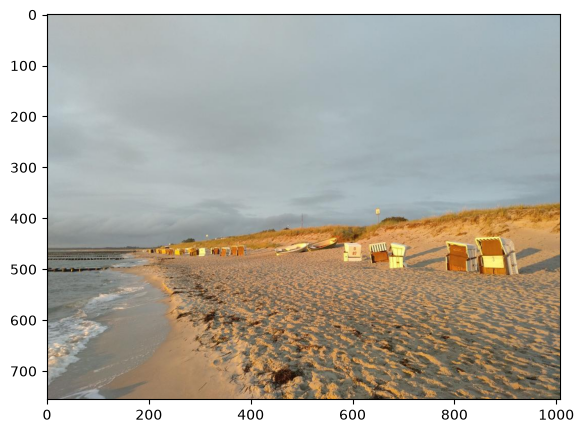

In [2]:
img = cv2.imread('../data/sea.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

### White patch
In white patch algorithm we choose a group of pixels we know they should be white. We then scale the resulting image colour channels by this white patch.

(<Axes: >, <matplotlib.image.AxesImage at 0x2b542ea1310>)

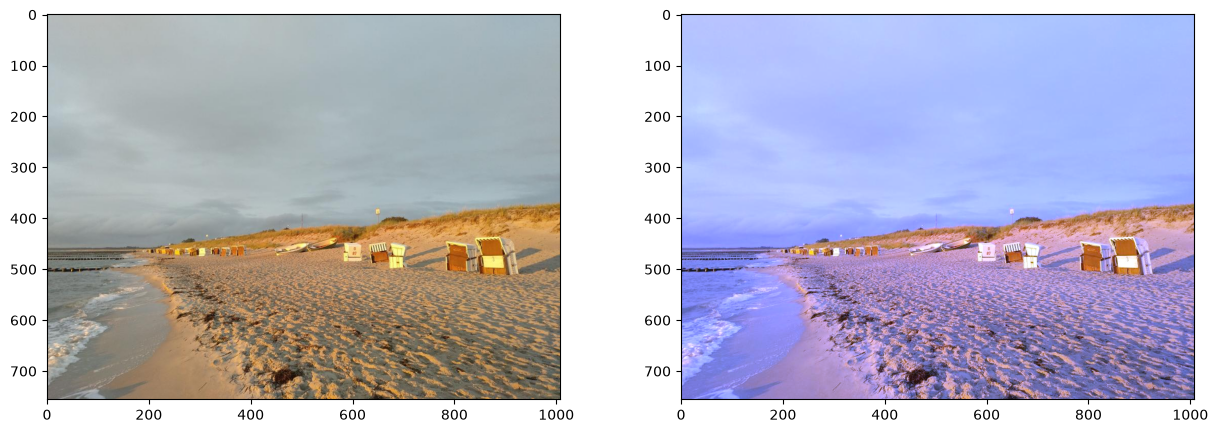

In [3]:
# Define white patch and the coefficients
row, col = 485, 864 
white = img[row, col, :]
coeffs = 255.0/white

# Apply white balancing and generate balanced image
balanced = np.zeros_like(img, dtype=np.float32)
for channel in range(3):
    balanced[..., channel] = img[..., channel] * coeffs[channel]

# White patching does not guarantee that the dynamic range is preserved, images must be clipped.
balanced = balanced/255
balanced[balanced > 1] = 1

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

### Gray world
This algorithm assumes that a scene, on average, is gray.

162.25918577307465 156.81538170823885 144.0787745653817


(<Axes: >, <matplotlib.image.AxesImage at 0x2b54a692d50>)

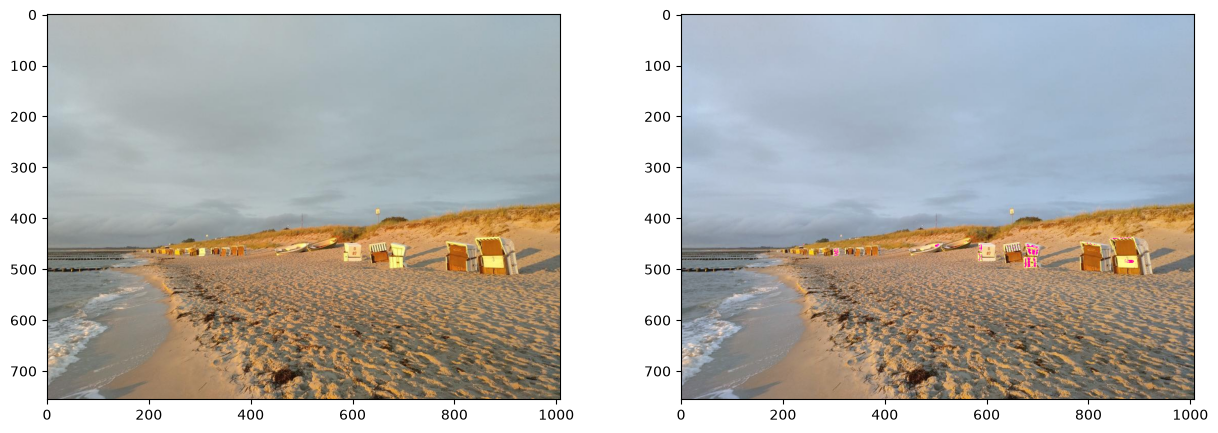

In [44]:
# Load your image
img = cv2.imread('../data/sea.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the mean values for all three colour channels (red, green, blue)
r, g, b = cv2.split(img)

mean_r = np.mean(r)
mean_g = np.mean(g)
mean_b = np.mean(b)

# Compute the coefficients kr, kg, kb
# Note: there are 3 coefficients to compute but we only have 2 equations.
# Therefore, you have to make an assumption, fix the value of one of the
# coefficients and compute the remaining two
# Hint: You can fix the coefficient of the brightest colour channel to 1.
print(mean_r, mean_g, mean_b) # mean_r is the brightest
kr = 1
kg = mean_r / mean_g
kb = mean_r / mean_b

balanced_r = np.uint8(r * kr)
balanced_g = np.uint8(g * kg)
balanced_b = np.uint8(b * kb)

# Apply color balancing and generate the balanced image
balanced = np.stack([balanced_r, balanced_g, balanced_b], axis=2)
balanced[balanced > 255] = 255

# Show the original and the balanced image side by side
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

### Scale-by-max
This is a straightforward algorithm that scales each colour channel by its maximum value. Note that it is sensitive to noise and saturations.

(<Axes: >, <matplotlib.image.AxesImage at 0x2b5470039d0>)

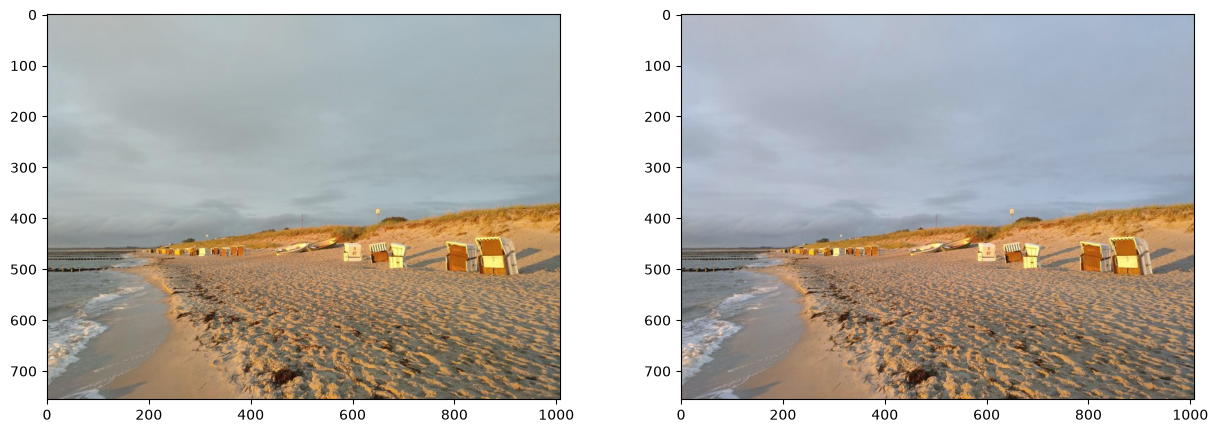

In [35]:
# Load your image
img = cv2.imread('../data/sea.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the maximum values for all three colour channels (red, green, blue)
r, g, b = cv2.split(img)

max_r = np.max(r)
max_g = np.max(g)
max_b = np.max(b)

balanced_r = np.uint8(r / max_r * 255.0)
balanced_g = np.uint8(g / max_g * 255.0)
balanced_b = np.uint8(b / max_b * 255.0)

# Apply scale-by-max balancing and generate the balanced image
balanced = np.stack([balanced_r, balanced_g, balanced_b], axis=2)

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)